In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("/concertriccir2.csv", header=None)

df.columns = ["X", "Y", "class"]

df["class"] = df["class"].astype(int)

df.head()

,X,Y,class
0,0.700335,-0.247068,0
1,-3.950019,2.740080,1
2,0.150222,-2.157638,1
3,-1.672050,-0.941519,1
4,2.560483,-1.846577,1


In [3]:
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Classes:", sorted(df["class"].unique()))

display(df.describe())

Dataset Shape: (500, 3)
Missing Values: 0
Classes: [np.int64(0), np.int64(1)]


,X,Y,class
count,500.000000,500.000000,500.000000
mean,1.883707,1.869874,0.500000
std,1.931275,1.986852,0.500501
min,-3.950019,-3.935098,0.000000
25%,0.403585,0.426457,0.000000
50%,2.191547,2.109658,0.500000
75%,3.349001,3.388552,1.000000
max,6.712027,7.848278,1.000000


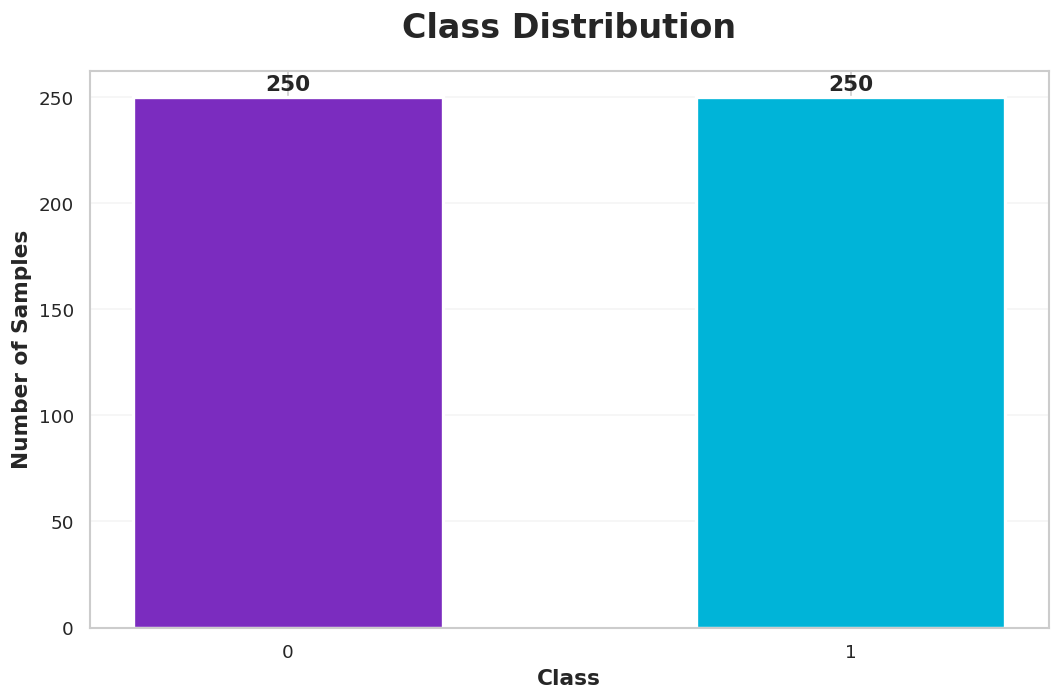

In [4]:
class_counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(9, 6))

bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values,
    width=0.55,
    color=["#7B2CBF", "#00B4D8"],
    edgecolor="white",
    linewidth=2
)

plt.title("Class Distribution", fontsize=20, pad=20)
plt.xlabel("Class", fontsize=13)
plt.ylabel("Number of Samples", fontsize=13)

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 3,
        str(value),
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

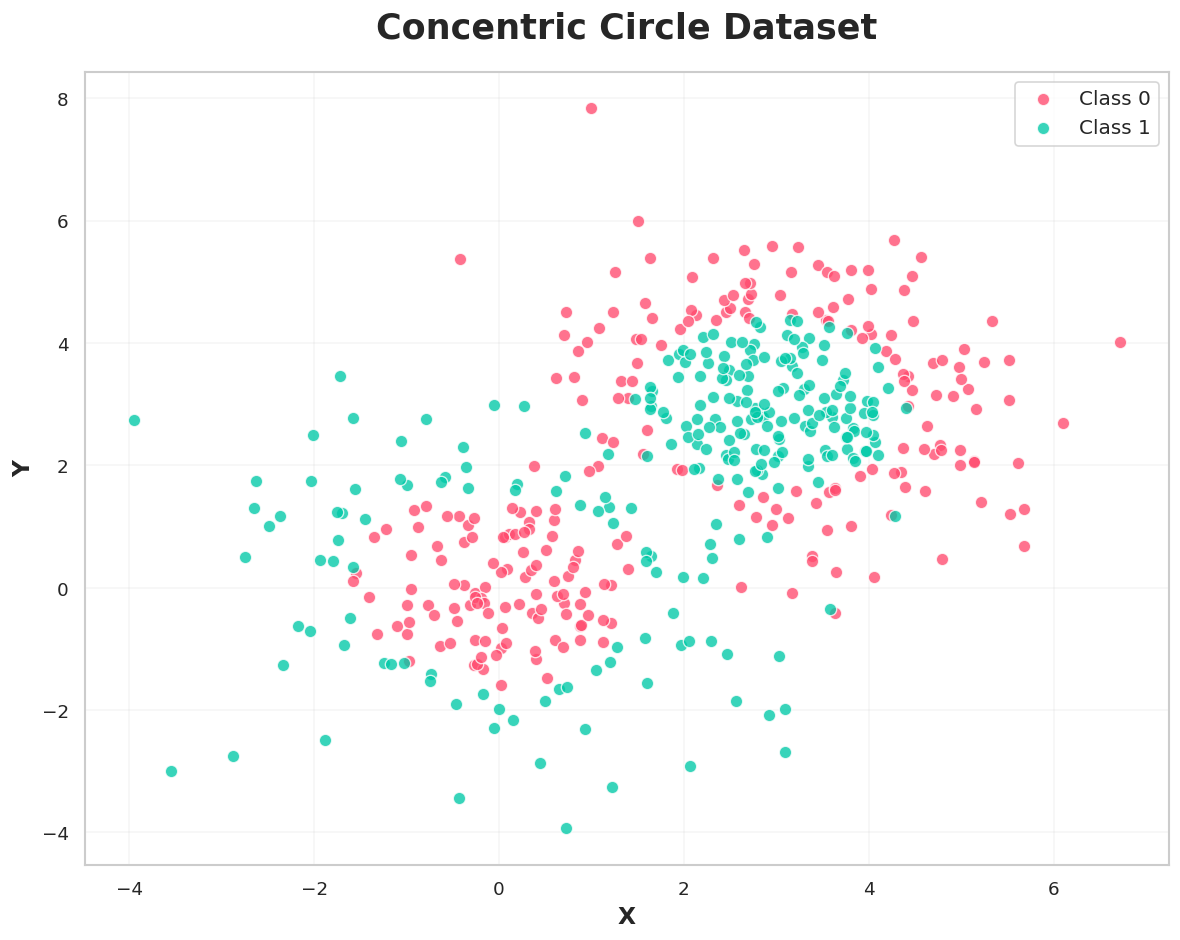

In [5]:
plt.figure(figsize=(10, 8))

colors = {
    0: "#FF4B6E",
    1: "#00C9A7"
}

labels = {
    0: "Class 0",
    1: "Class 1"
}

for label in sorted(df["class"].unique()):
    subset = df[df["class"] == label]

    plt.scatter(
        subset["X"],
        subset["Y"],
        s=55,
        c=colors[label],
        alpha=0.78,
        edgecolors="white",
        linewidths=0.8,
        label=labels[label]
    )

plt.title("Concentric Circle Dataset", fontsize=21, pad=20)
plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

In [6]:
X = df[["X", "Y"]].values.astype(np.float32)
y = df["class"].values.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))
print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

Training Samples: 400
Validation Samples: 100
Training Shape: (400, 2)
Validation Shape: (100, 2)


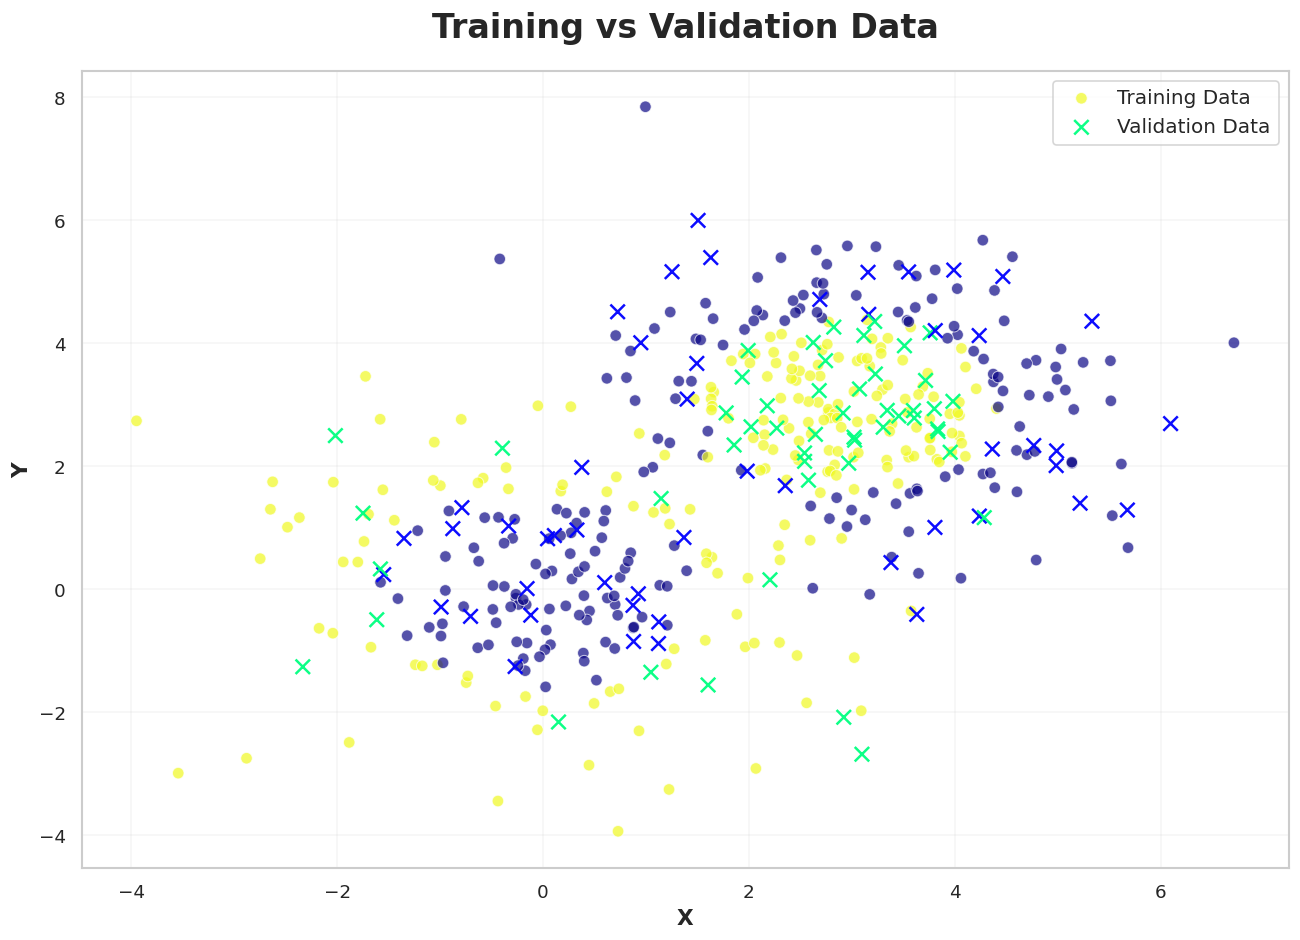

In [7]:
plt.figure(figsize=(11, 8))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="plasma",
    s=48,
    alpha=0.7,
    edgecolors="white",
    linewidths=0.6,
    label="Training Data"
)

plt.scatter(
    X_val[:, 0],
    X_val[:, 1],
    c=y_val,
    cmap="winter",
    s=75,
    alpha=0.95,
    marker="x",
    linewidths=1.5,
    label="Validation Data"
)

plt.title("Training vs Validation Data", fontsize=20, pad=20)
plt.xlabel("X", fontsize=13)
plt.ylabel("Y", fontsize=13)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

In [8]:
model_without_bn = Sequential([
    Dense(2, activation="relu", input_dim=2),
    Dense(2, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_without_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_without_bn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_without_bn = model_without_bn.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4850 - loss: 1.2460 - val_accuracy: 0.4900 - val_loss: 1.2977
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4875 - loss: 1.1847 - val_accuracy: 0.4800 - val_loss: 1.2316
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4825 - loss: 1.1280 - val_accuracy: 0.4800 - val_loss: 1.1706
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4775 - loss: 1.0761 - val_accuracy: 0.4500 - val_loss: 1.1149
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4625 - loss: 1.0292 - val_accuracy: 0.4500 - val_loss: 1.0643
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4525 - loss: 0.9870 - val_accuracy: 0.4500 - val_loss: 1.0186
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4425 - loss: 0.9492 - val_accuracy: 0.4600 - val_loss: 0.9778
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4350 - loss: 0.9153 - val_accuracy: 0.

In [10]:
model_with_bn = Sequential([
    Dense(3, activation="relu", input_dim=2),
    BatchNormalization(),
    Dense(2, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")
])

model_with_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_with_bn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [11]:
history_with_bn = model_with_bn.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5175 - loss: 0.7872 - val_accuracy: 0.4400 - val_loss: 1.4403
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5150 - loss: 0.7760 - val_accuracy: 0.4000 - val_loss: 1.3260
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5125 - loss: 0.7668 - val_accuracy: 0.3500 - val_loss: 1.2313
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5175 - loss: 0.7582 - val_accuracy: 0.3500 - val_loss: 1.1483
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5175 - loss: 0.7499 - val_accuracy: 0.3300 - val_loss: 1.0744
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5225 - loss: 0.7422 - val_accuracy: 0.3300 - val_loss: 1.0104
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5200 - loss: 0.7349 - val_accuracy: 0.3200 - val_loss: 0.9552
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5175 - loss: 0.7285 - val_accuracy: 0.3300 - 

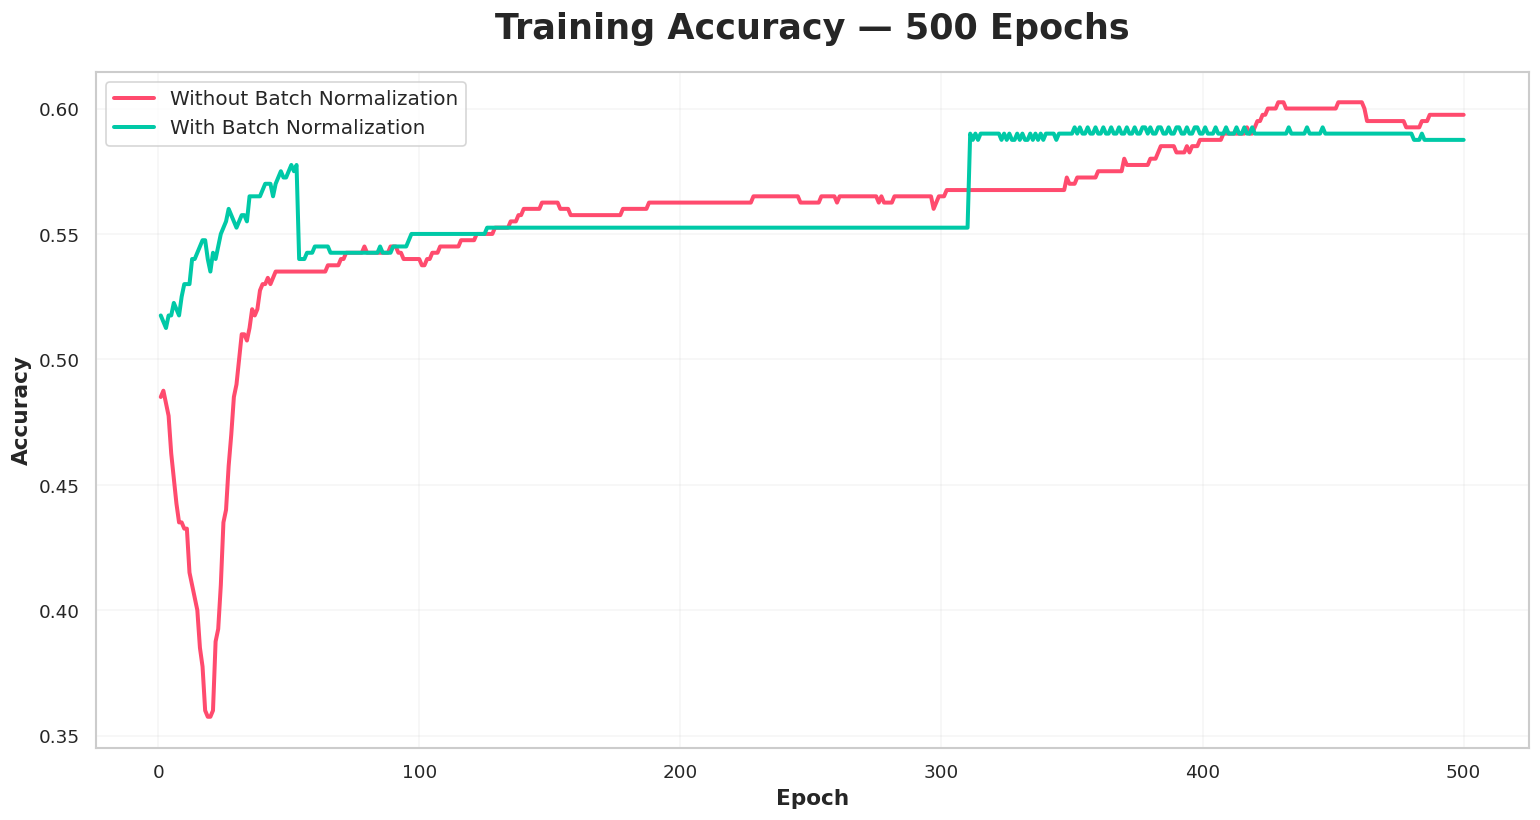

In [12]:
epochs = range(1, 501)

plt.figure(figsize=(13, 7))

plt.plot(
    epochs,
    history_without_bn.history["accuracy"],
    color="#FF4B6E",
    linewidth=2.4,
    label="Without Batch Normalization"
)

plt.plot(
    epochs,
    history_with_bn.history["accuracy"],
    color="#00C9A7",
    linewidth=2.4,
    label="With Batch Normalization"
)

plt.title("Training Accuracy — 500 Epochs", fontsize=21, pad=20)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

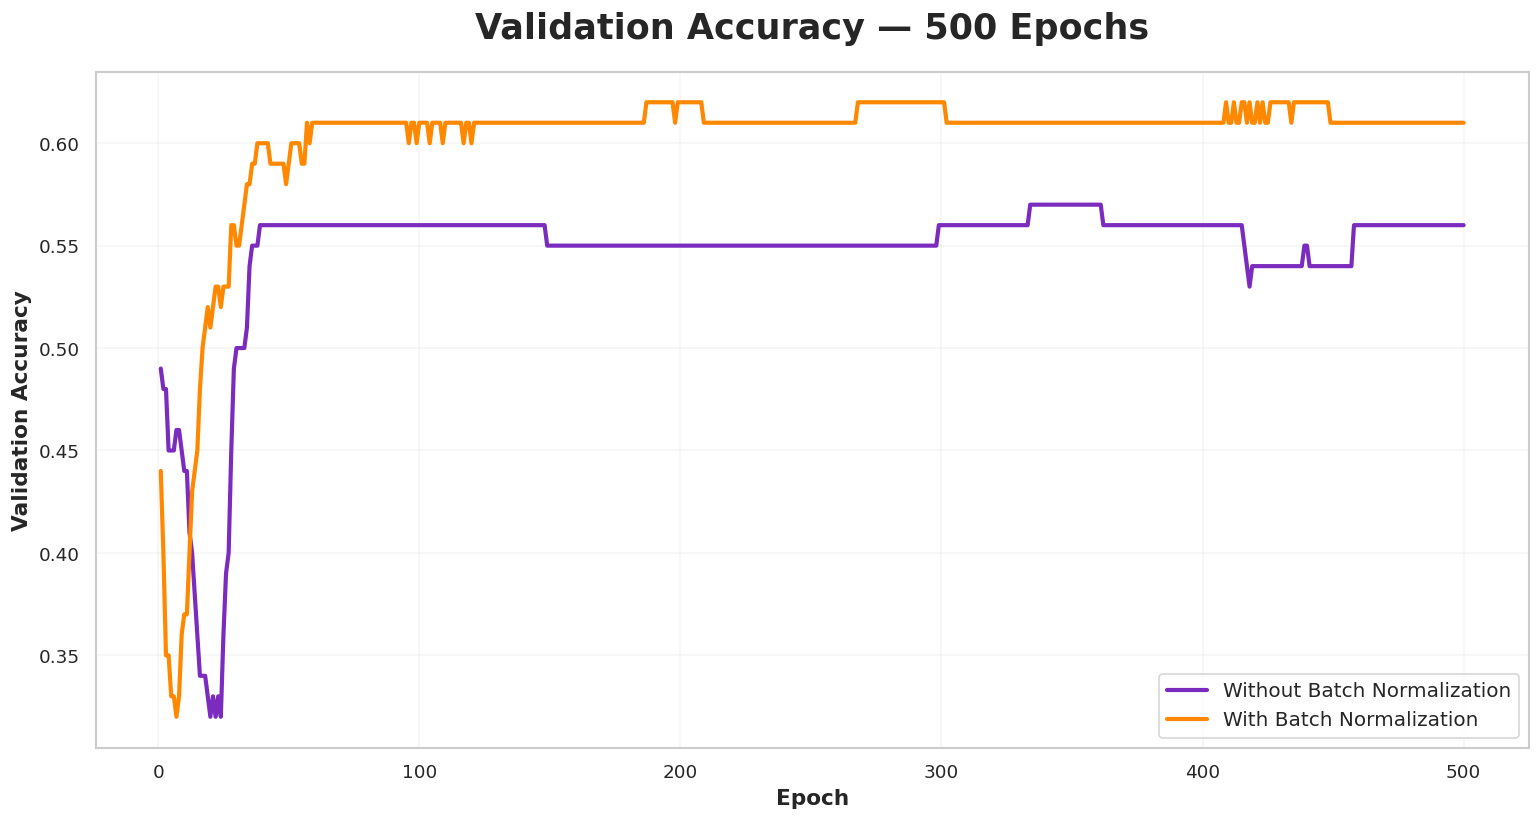

In [13]:
plt.figure(figsize=(13, 7))

plt.plot(
    epochs,
    history_without_bn.history["val_accuracy"],
    color="#7B2CBF",
    linewidth=2.5,
    label="Without Batch Normalization"
)

plt.plot(
    epochs,
    history_with_bn.history["val_accuracy"],
    color="#FF8800",
    linewidth=2.5,
    label="With Batch Normalization"
)

plt.title("Validation Accuracy — 500 Epochs", fontsize=21, pad=20)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Validation Accuracy", fontsize=13)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

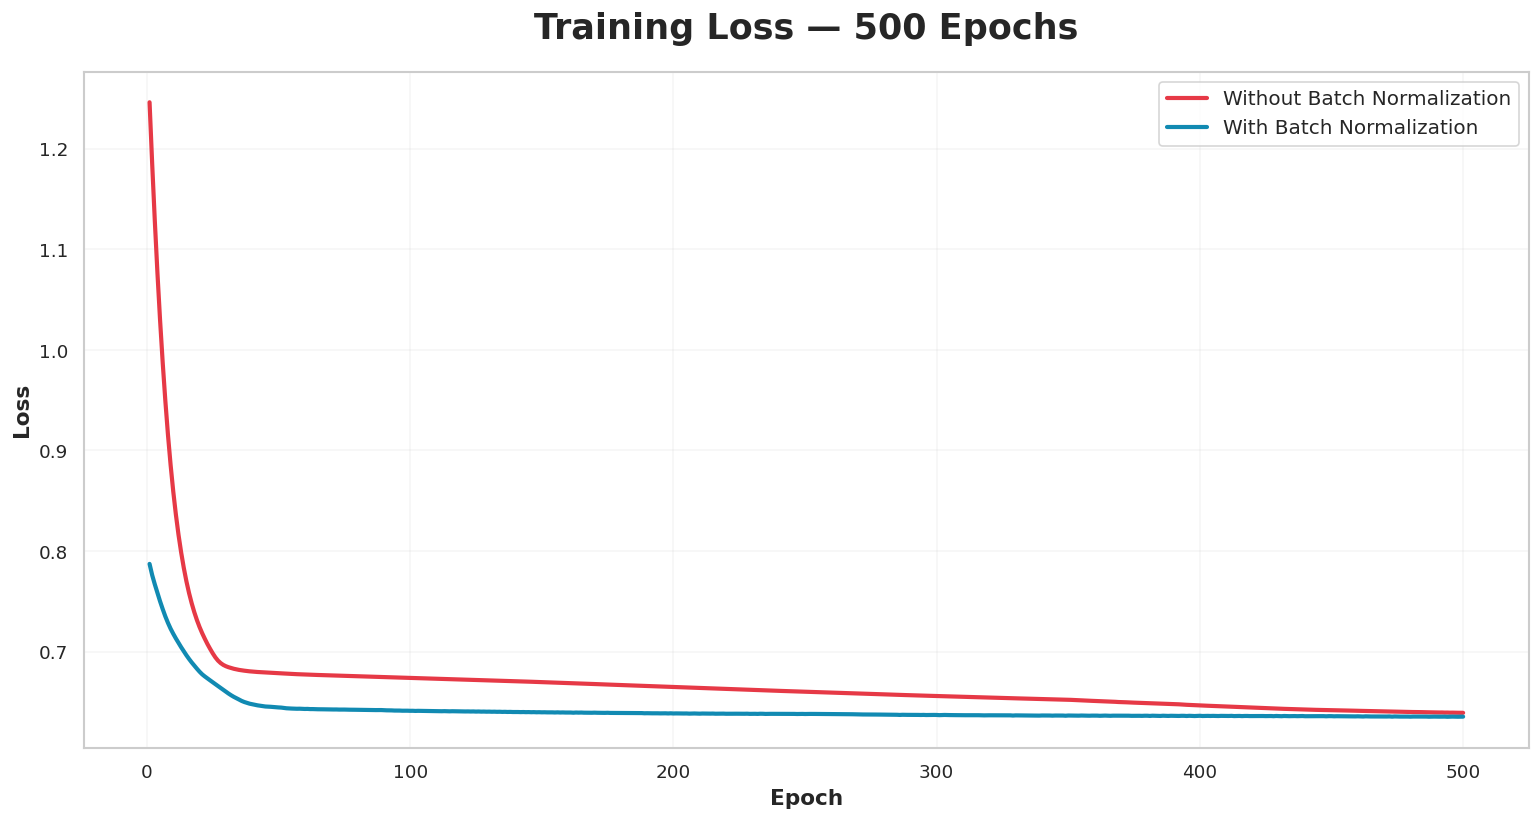

In [14]:
plt.figure(figsize=(13, 7))

plt.plot(
    epochs,
    history_without_bn.history["loss"],
    color="#E63946",
    linewidth=2.5,
    label="Without Batch Normalization"
)

plt.plot(
    epochs,
    history_with_bn.history["loss"],
    color="#118AB2",
    linewidth=2.5,
    label="With Batch Normalization"
)

plt.title("Training Loss — 500 Epochs", fontsize=21, pad=20)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

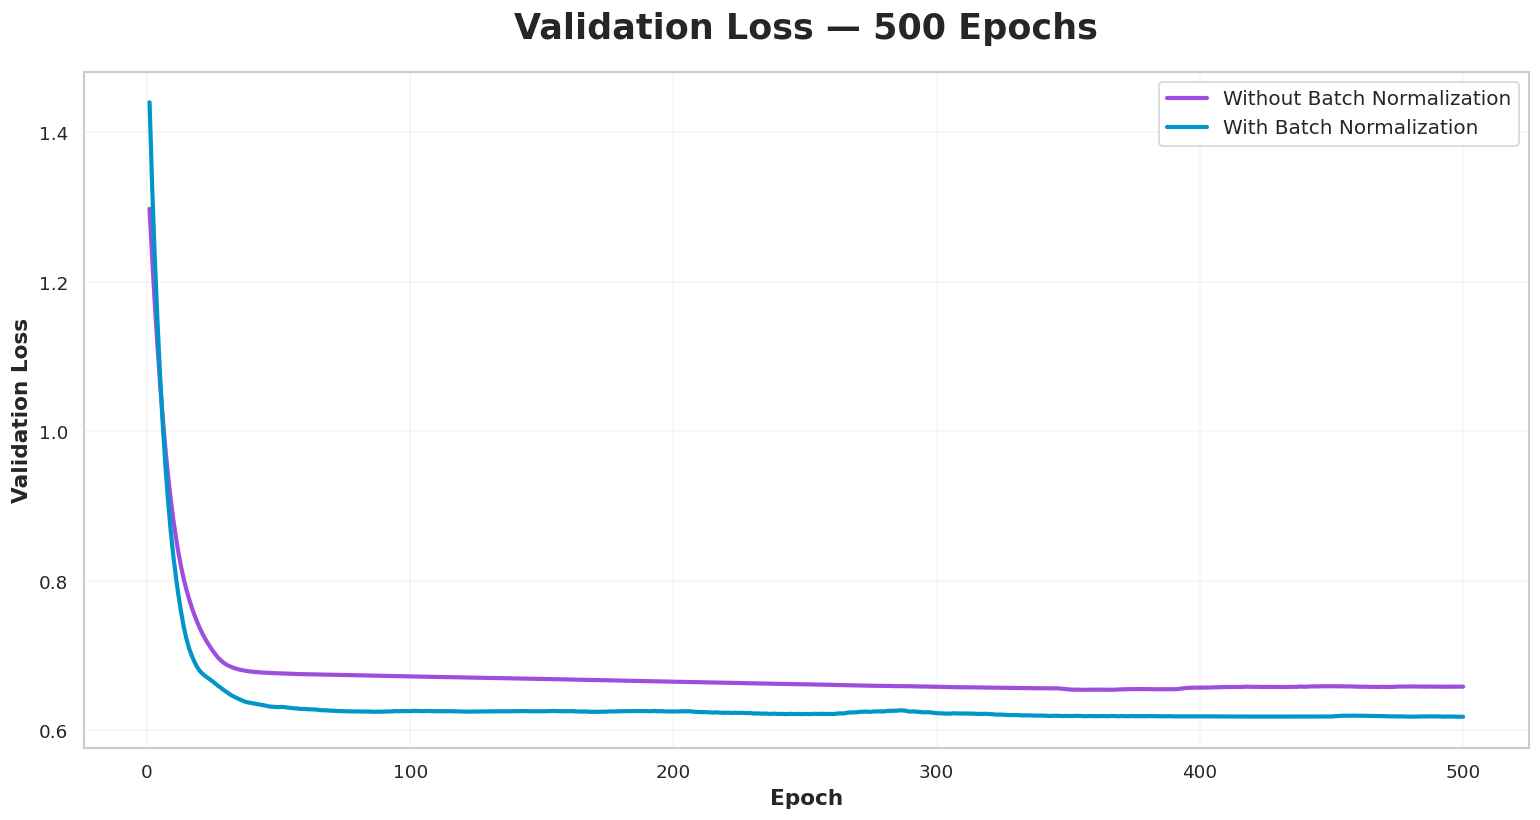

In [15]:
plt.figure(figsize=(13, 7))

plt.plot(
    epochs,
    history_without_bn.history["val_loss"],
    color="#9D4EDD",
    linewidth=2.5,
    label="Without Batch Normalization"
)

plt.plot(
    epochs,
    history_with_bn.history["val_loss"],
    color="#0096C7",
    linewidth=2.5,
    label="With Batch Normalization"
)

plt.title("Validation Loss — 500 Epochs", fontsize=21, pad=20)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Validation Loss", fontsize=13)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

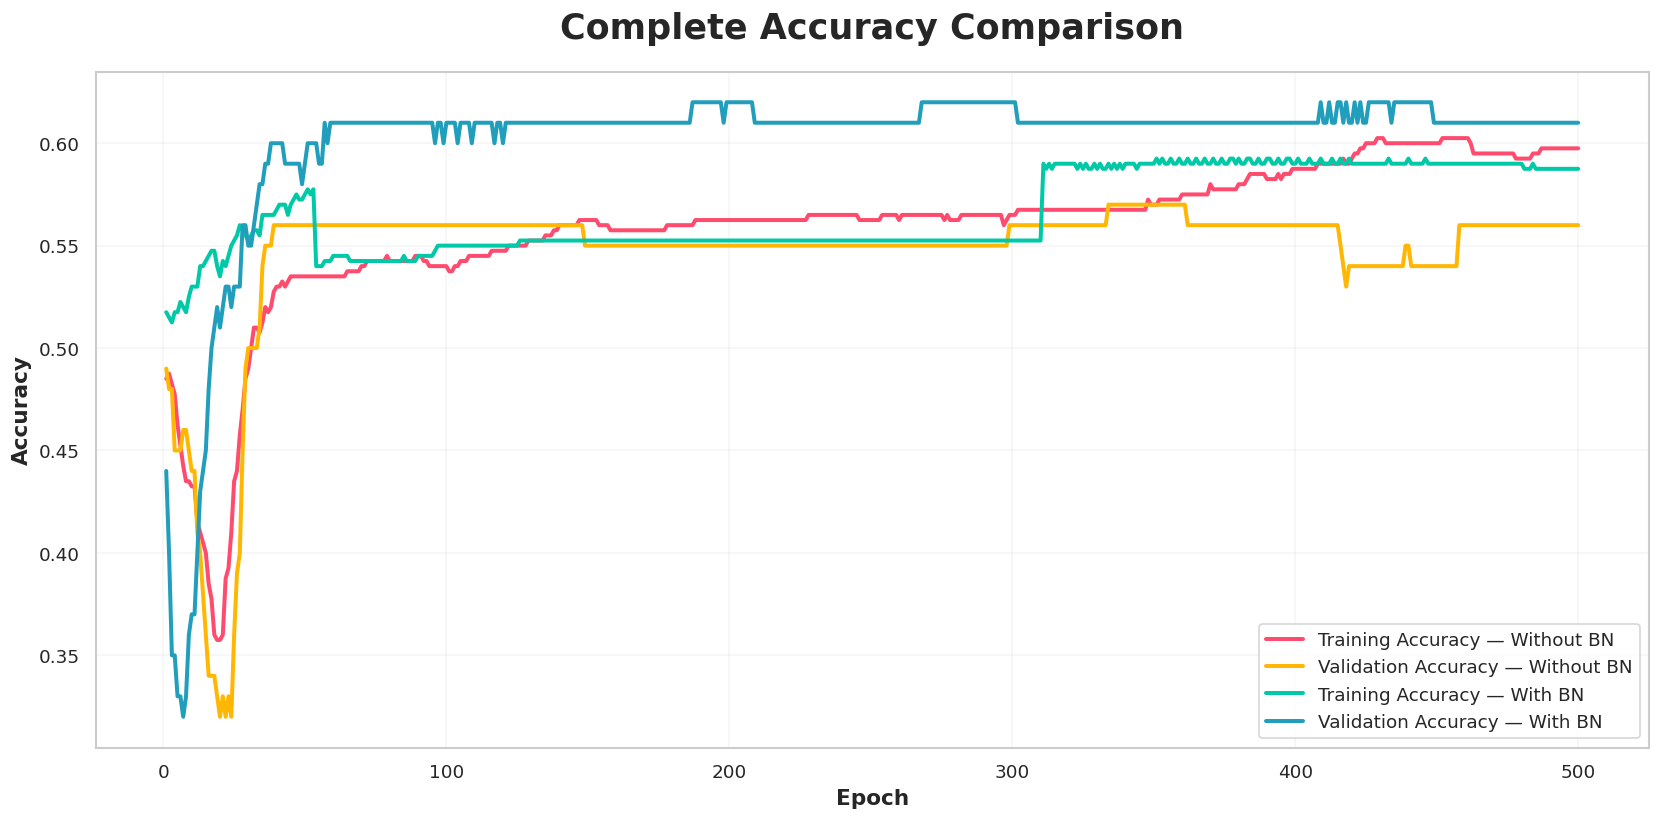

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    history_without_bn.history["accuracy"],
    color="#FF4B6E",
    linewidth=2.4,
    label="Training Accuracy — Without BN"
)

ax.plot(
    epochs,
    history_without_bn.history["val_accuracy"],
    color="#FFB703",
    linewidth=2.4,
    label="Validation Accuracy — Without BN"
)

ax.plot(
    epochs,
    history_with_bn.history["accuracy"],
    color="#00C9A7",
    linewidth=2.4,
    label="Training Accuracy — With BN"
)

ax.plot(
    epochs,
    history_with_bn.history["val_accuracy"],
    color="#219EBC",
    linewidth=2.4,
    label="Validation Accuracy — With BN"
)

ax.set_title("Complete Accuracy Comparison", fontsize=21, pad=20)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Accuracy", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

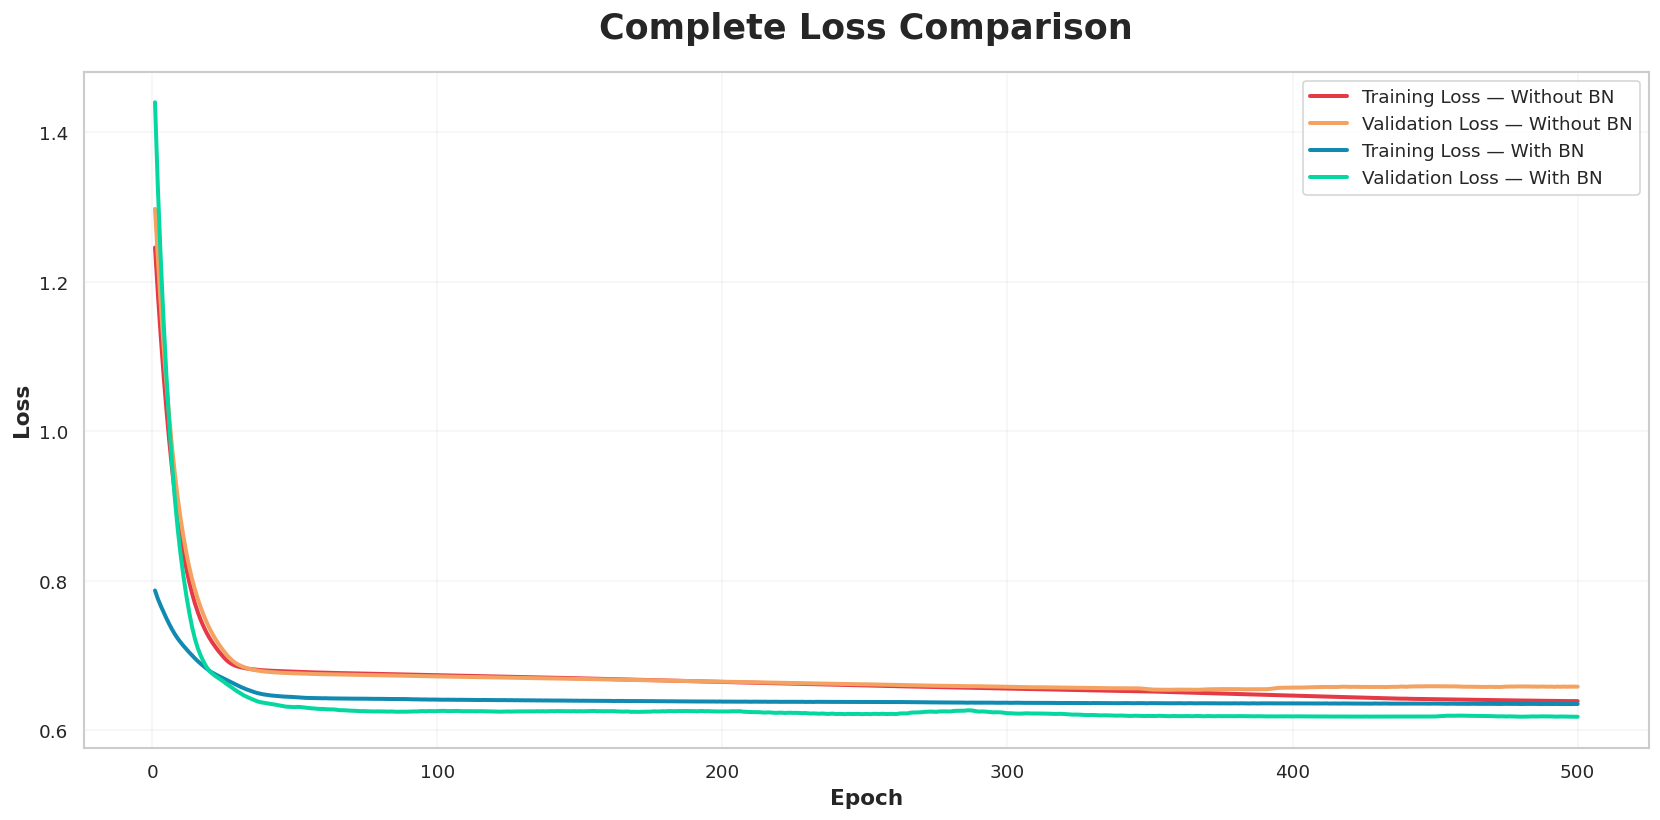

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    history_without_bn.history["loss"],
    color="#E63946",
    linewidth=2.4,
    label="Training Loss — Without BN"
)

ax.plot(
    epochs,
    history_without_bn.history["val_loss"],
    color="#F4A261",
    linewidth=2.4,
    label="Validation Loss — Without BN"
)

ax.plot(
    epochs,
    history_with_bn.history["loss"],
    color="#118AB2",
    linewidth=2.4,
    label="Training Loss — With BN"
)

ax.plot(
    epochs,
    history_with_bn.history["val_loss"],
    color="#06D6A0",
    linewidth=2.4,
    label="Validation Loss — With BN"
)

ax.set_title("Complete Loss Comparison", fontsize=21, pad=20)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

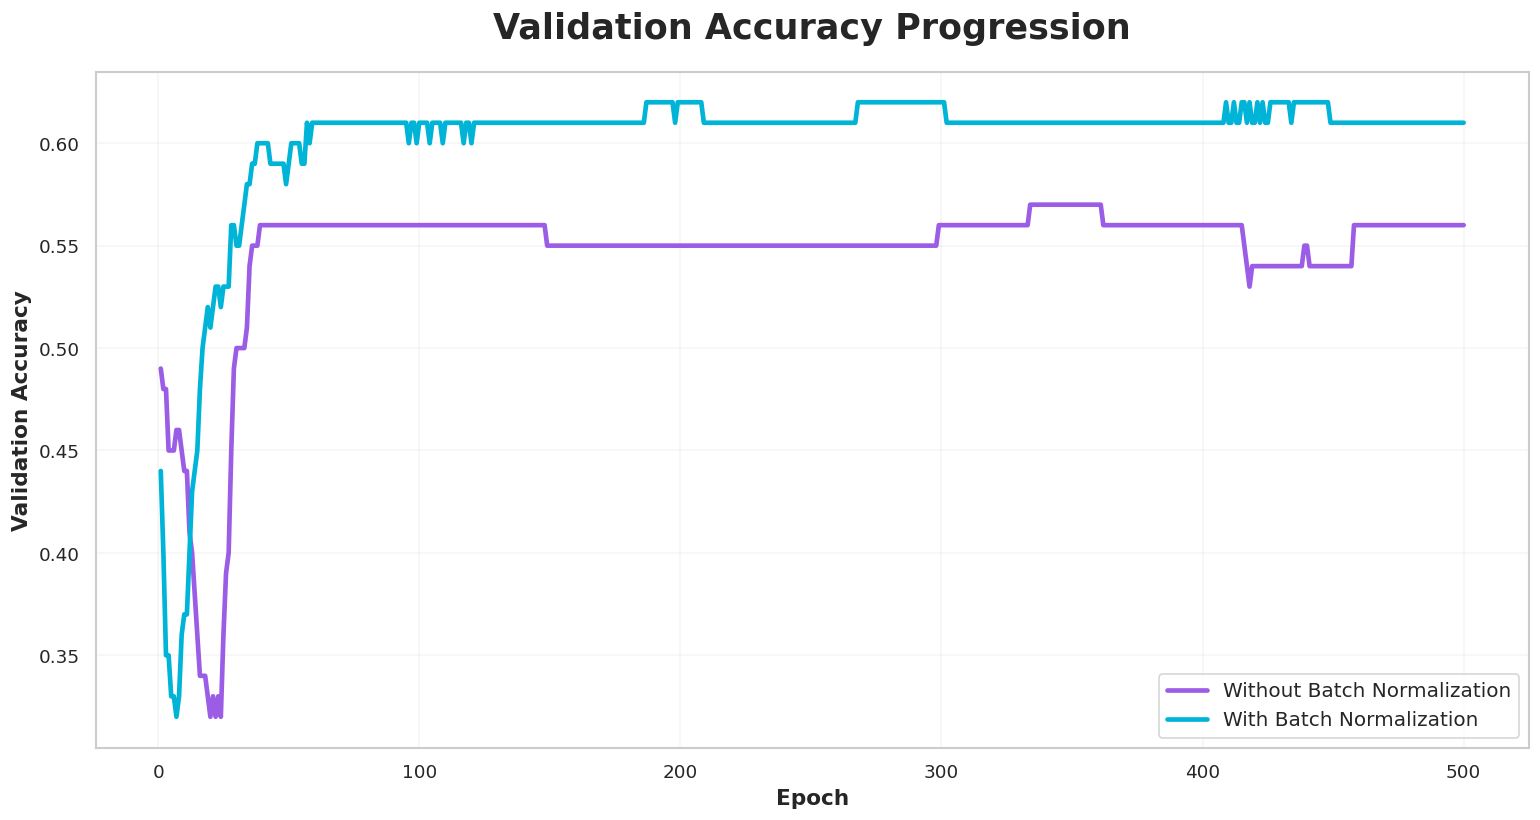

In [18]:
start_epoch = 1

plt.figure(figsize=(13, 7))

plt.plot(
    range(start_epoch, 501),
    history_without_bn.history["val_accuracy"][start_epoch - 1:],
    color="#9B5DE5",
    linewidth=2.8,
    label="Without Batch Normalization"
)

plt.plot(
    range(start_epoch, 501),
    history_with_bn.history["val_accuracy"][start_epoch - 1:],
    color="#00B4D8",
    linewidth=2.8,
    label="With Batch Normalization"
)

plt.title("Validation Accuracy Progression", fontsize=21, pad=20)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Validation Accuracy", fontsize=13)
plt.legend(fontsize=12)
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

In [19]:
loss_without_bn, accuracy_without_bn = model_without_bn.evaluate(
    X_val,
    y_val,
    verbose=0
)

loss_with_bn, accuracy_with_bn = model_with_bn.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Without Batch Normalization")
print("Validation Loss:", loss_without_bn)
print("Validation Accuracy:", accuracy_without_bn)

print("\nWith Batch Normalization")
print("Validation Loss:", loss_with_bn)
print("Validation Accuracy:", accuracy_with_bn)

Without Batch Normalization
Validation Loss: 0.6584902405738831
Validation Accuracy: 0.5600000023841858

With Batch Normalization
Validation Loss: 0.6182252168655396
Validation Accuracy: 0.6100000143051147


In [20]:
results = pd.DataFrame({
    "Model": [
        "Without Batch Normalization",
        "With Batch Normalization"
    ],
    "Validation Loss": [
        loss_without_bn,
        loss_with_bn
    ],
    "Validation Accuracy": [
        accuracy_without_bn,
        accuracy_with_bn
    ],
    "Best Validation Accuracy": [
        max(history_without_bn.history["val_accuracy"]),
        max(history_with_bn.history["val_accuracy"])
    ]
})

display(
    results.style
    .format({
        "Validation Loss": "{:.6f}",
        "Validation Accuracy": "{:.4%}",
        "Best Validation Accuracy": "{:.4%}"
    })
    .background_gradient(cmap="viridis")
)

,Model,Validation Loss,Validation Accuracy,Best Validation Accuracy
0,Without Batch Normalization,0.658490,56.0000%,57.0000%
1,With Batch Normalization,0.618225,61.0000%,62.0000%


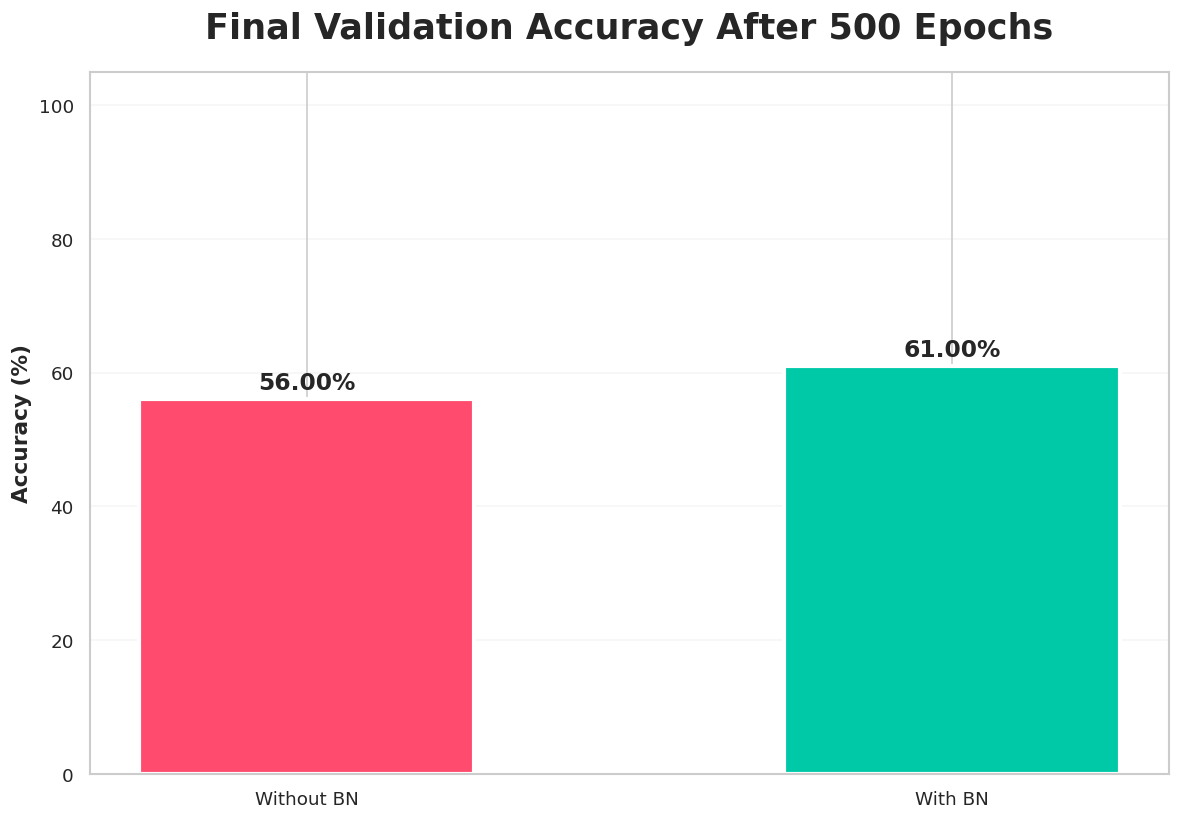

In [21]:
models = [
    "Without BN",
    "With BN"
]

values = [
    accuracy_without_bn * 100,
    accuracy_with_bn * 100
]

plt.figure(figsize=(10, 7))

bars = plt.bar(
    models,
    values,
    width=0.52,
    color=["#FF4B6E", "#00C9A7"],
    edgecolor="white",
    linewidth=2.5
)

plt.title("Final Validation Accuracy After 500 Epochs", fontsize=21, pad=20)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.ylim(0, 105)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

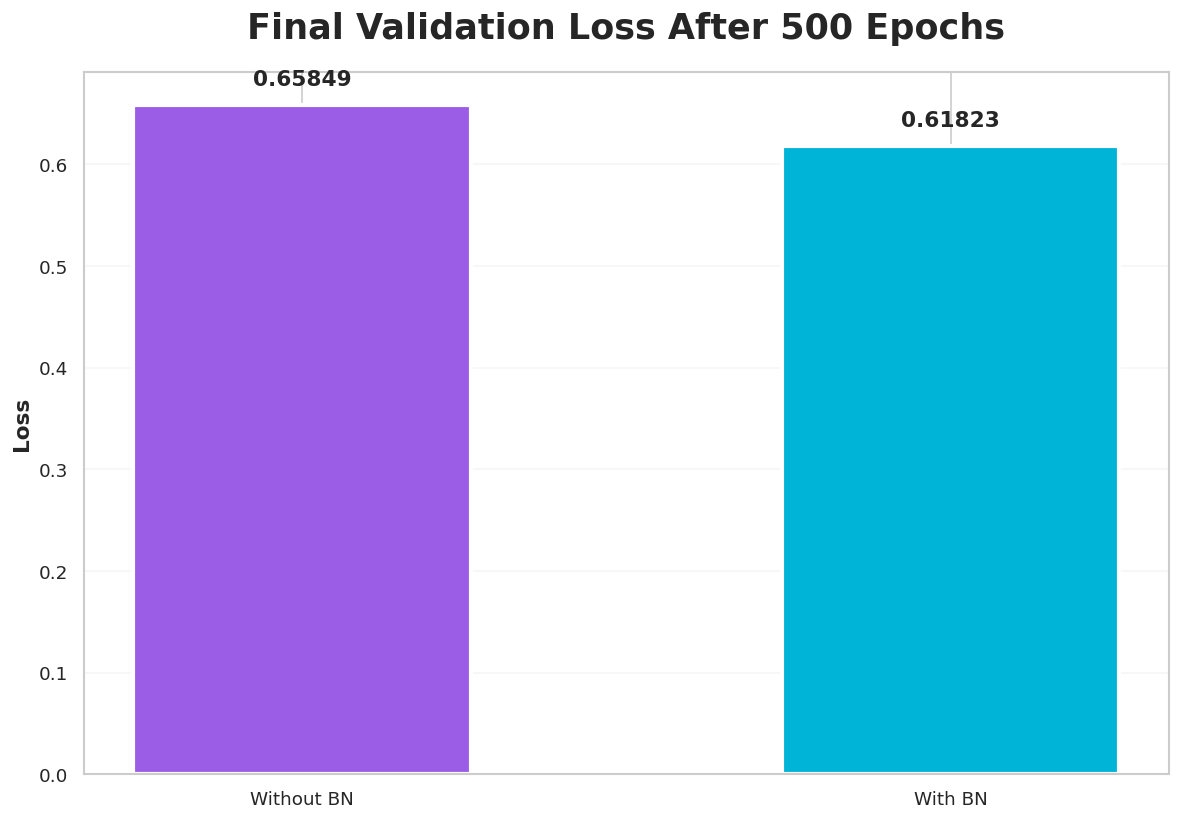

In [22]:
loss_values = [
    loss_without_bn,
    loss_with_bn
]

plt.figure(figsize=(10, 7))

bars = plt.bar(
    models,
    loss_values,
    width=0.52,
    color=["#9B5DE5", "#00B4D8"],
    edgecolor="white",
    linewidth=2.5
)

plt.title("Final Validation Loss After 500 Epochs", fontsize=21, pad=20)
plt.ylabel("Loss", fontsize=13)

for bar, value in zip(bars, loss_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(loss_values) * 0.03,
        f"{value:.5f}",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

In [23]:
pred_without_bn_prob = model_without_bn.predict(X_val, verbose=0).ravel()
pred_with_bn_prob = model_with_bn.predict(X_val, verbose=0).ravel()

pred_without_bn = (pred_without_bn_prob >= 0.5).astype(int)
pred_with_bn = (pred_with_bn_prob >= 0.5).astype(int)

accuracy_without_bn_manual = accuracy_score(
    y_val,
    pred_without_bn
)

accuracy_with_bn_manual = accuracy_score(
    y_val,
    pred_with_bn
)

print("Manual Accuracy Without BN:", accuracy_without_bn_manual)
print("Manual Accuracy With BN:", accuracy_with_bn_manual)

Manual Accuracy Without BN: 0.56
Manual Accuracy With BN: 0.61


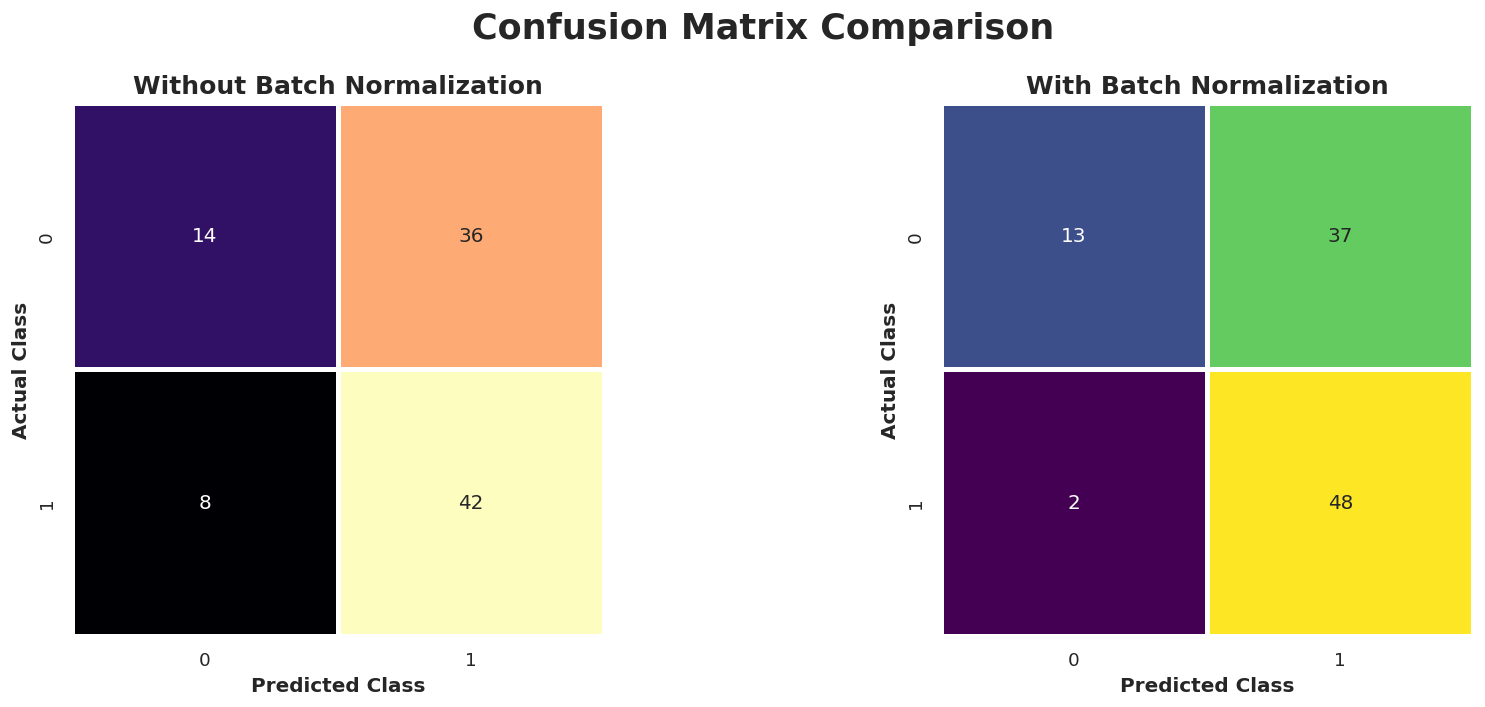

In [24]:
cm_without_bn = confusion_matrix(
    y_val,
    pred_without_bn
)

cm_with_bn = confusion_matrix(
    y_val,
    pred_with_bn
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.heatmap(
    cm_without_bn,
    annot=True,
    fmt="d",
    cmap="magma",
    cbar=False,
    square=True,
    linewidths=2,
    ax=axes[0]
)

sns.heatmap(
    cm_with_bn,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar=False,
    square=True,
    linewidths=2,
    ax=axes[1]
)

axes[0].set_title(
    "Without Batch Normalization",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_title(
    "With Batch Normalization",
    fontsize=15,
    fontweight="bold"
)

for ax in axes:
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=21,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [25]:
print("WITHOUT BATCH NORMALIZATION")
print(
    classification_report(
        y_val,
        pred_without_bn,
        target_names=["Class 0", "Class 1"]
    )
)

print("WITH BATCH NORMALIZATION")
print(
    classification_report(
        y_val,
        pred_with_bn,
        target_names=["Class 0", "Class 1"]
    )
)

WITHOUT BATCH NORMALIZATION
              precision    recall  f1-score   support

     Class 0       0.64      0.28      0.39        50
     Class 1       0.54      0.84      0.66        50

    accuracy                           0.56       100
   macro avg       0.59      0.56      0.52       100
weighted avg       0.59      0.56      0.52       100

WITH BATCH NORMALIZATION
              precision    recall  f1-score   support

     Class 0       0.87      0.26      0.40        50
     Class 1       0.56      0.96      0.71        50

    accuracy                           0.61       100
   macro avg       0.72      0.61      0.56       100
weighted avg       0.72      0.61      0.56       100



In [26]:
def plot_decision_boundary(model, title, cmap):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 600),
        np.linspace(y_min, y_max, 600)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(
        grid,
        verbose=0
    ).reshape(xx.shape)

    plt.figure(figsize=(11, 9))

    plt.contourf(
        xx,
        yy,
        predictions,
        levels=100,
        cmap=cmap,
        alpha=0.32
    )

    plt.contour(
        xx,
        yy,
        predictions,
        levels=[0.5],
        colors=["black"],
        linewidths=2.5
    )

    class_0 = df[df["class"] == 0]
    class_1 = df[df["class"] == 1]

    plt.scatter(
        class_0["X"],
        class_0["Y"],
        s=52,
        color="#FF4B6E",
        edgecolors="white",
        linewidths=0.8,
        alpha=0.9,
        label="Class 0"
    )

    plt.scatter(
        class_1["X"],
        class_1["Y"],
        s=52,
        color="#00C9A7",
        edgecolors="white",
        linewidths=0.8,
        alpha=0.9,
        label="Class 1"
    )

    plt.title(
        title,
        fontsize=21,
        pad=20
    )

    plt.xlabel("X", fontsize=13)
    plt.ylabel("Y", fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.12)

    plt.tight_layout()
    plt.show()

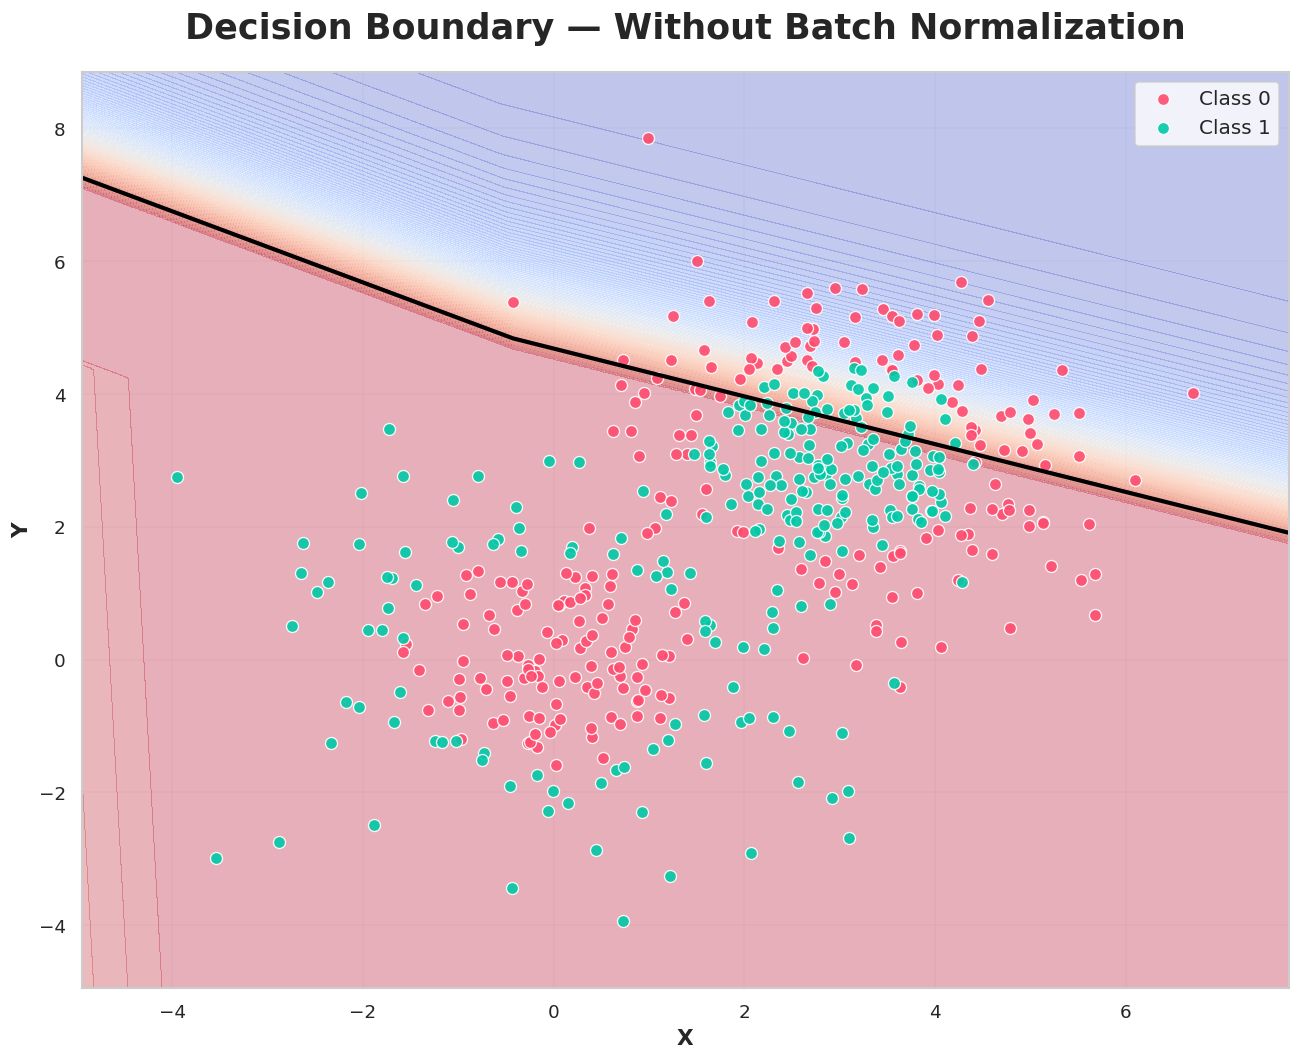

In [27]:
plot_decision_boundary(
    model_without_bn,
    "Decision Boundary — Without Batch Normalization",
    "coolwarm"
)

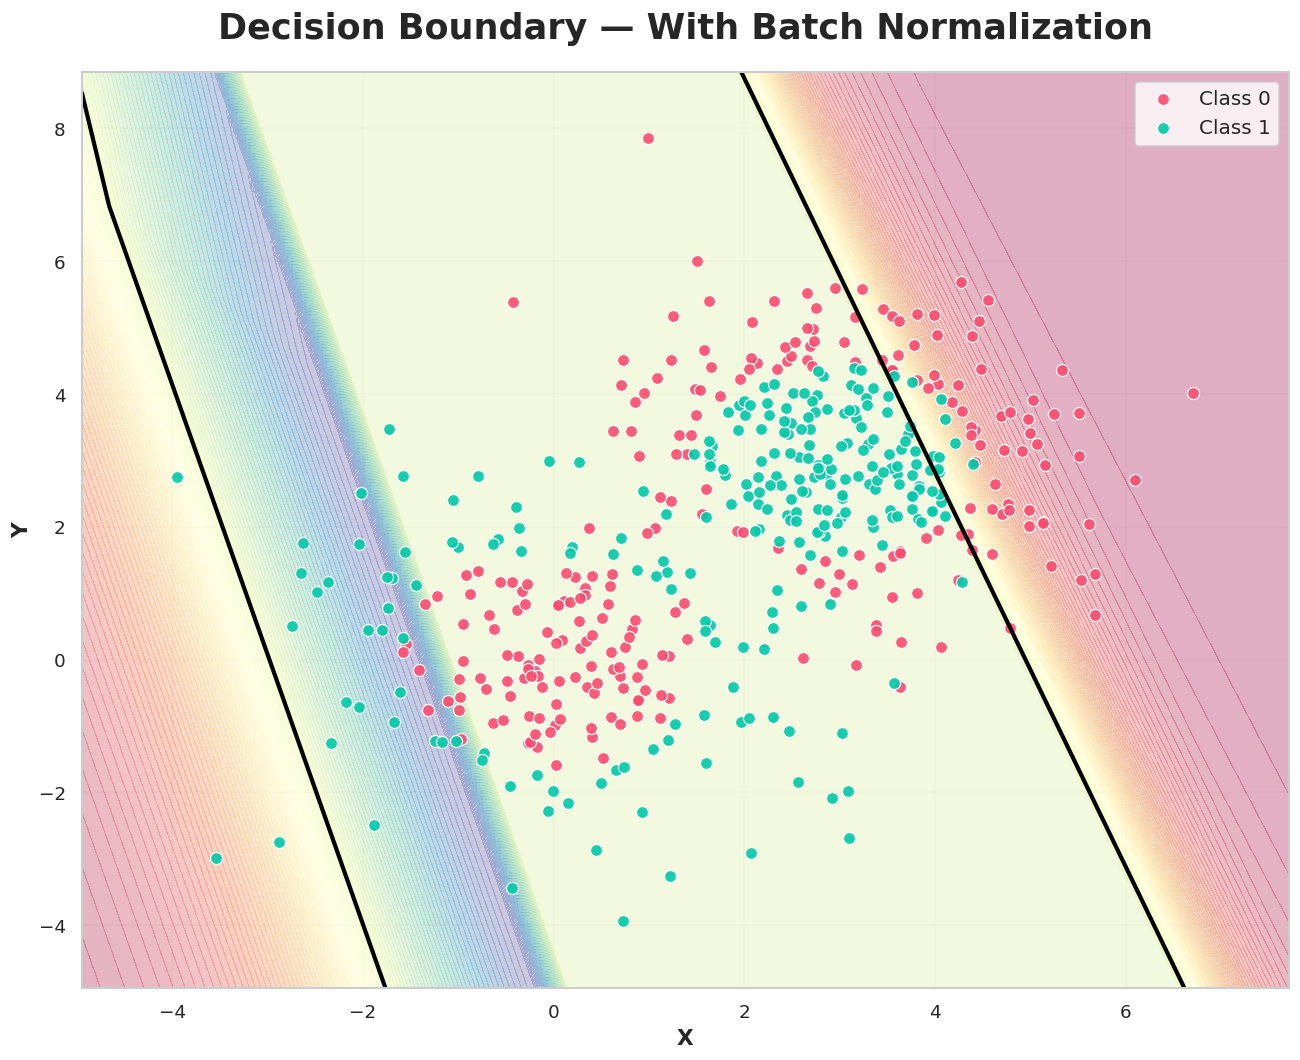

In [28]:
plot_decision_boundary(
    model_with_bn,
    "Decision Boundary — With Batch Normalization",
    "Spectral"
)

In [29]:
best_epoch_without_bn = (
    np.argmax(history_without_bn.history["val_accuracy"]) + 1
)

best_epoch_with_bn = (
    np.argmax(history_with_bn.history["val_accuracy"]) + 1
)

best_accuracy_without_bn = max(
    history_without_bn.history["val_accuracy"]
)

best_accuracy_with_bn = max(
    history_with_bn.history["val_accuracy"]
)

best_epoch_table = pd.DataFrame({
    "Model": [
        "Without Batch Normalization",
        "With Batch Normalization"
    ],
    "Best Epoch": [
        best_epoch_without_bn,
        best_epoch_with_bn
    ],
    "Best Validation Accuracy": [
        best_accuracy_without_bn,
        best_accuracy_with_bn
    ]
})

display(
    best_epoch_table.style
    .format({
        "Best Validation Accuracy": "{:.4%}"
    })
    .background_gradient(cmap="plasma")
)

,Model,Best Epoch,Best Validation Accuracy
0,Without Batch Normalization,334,57.0000%
1,With Batch Normalization,187,62.0000%


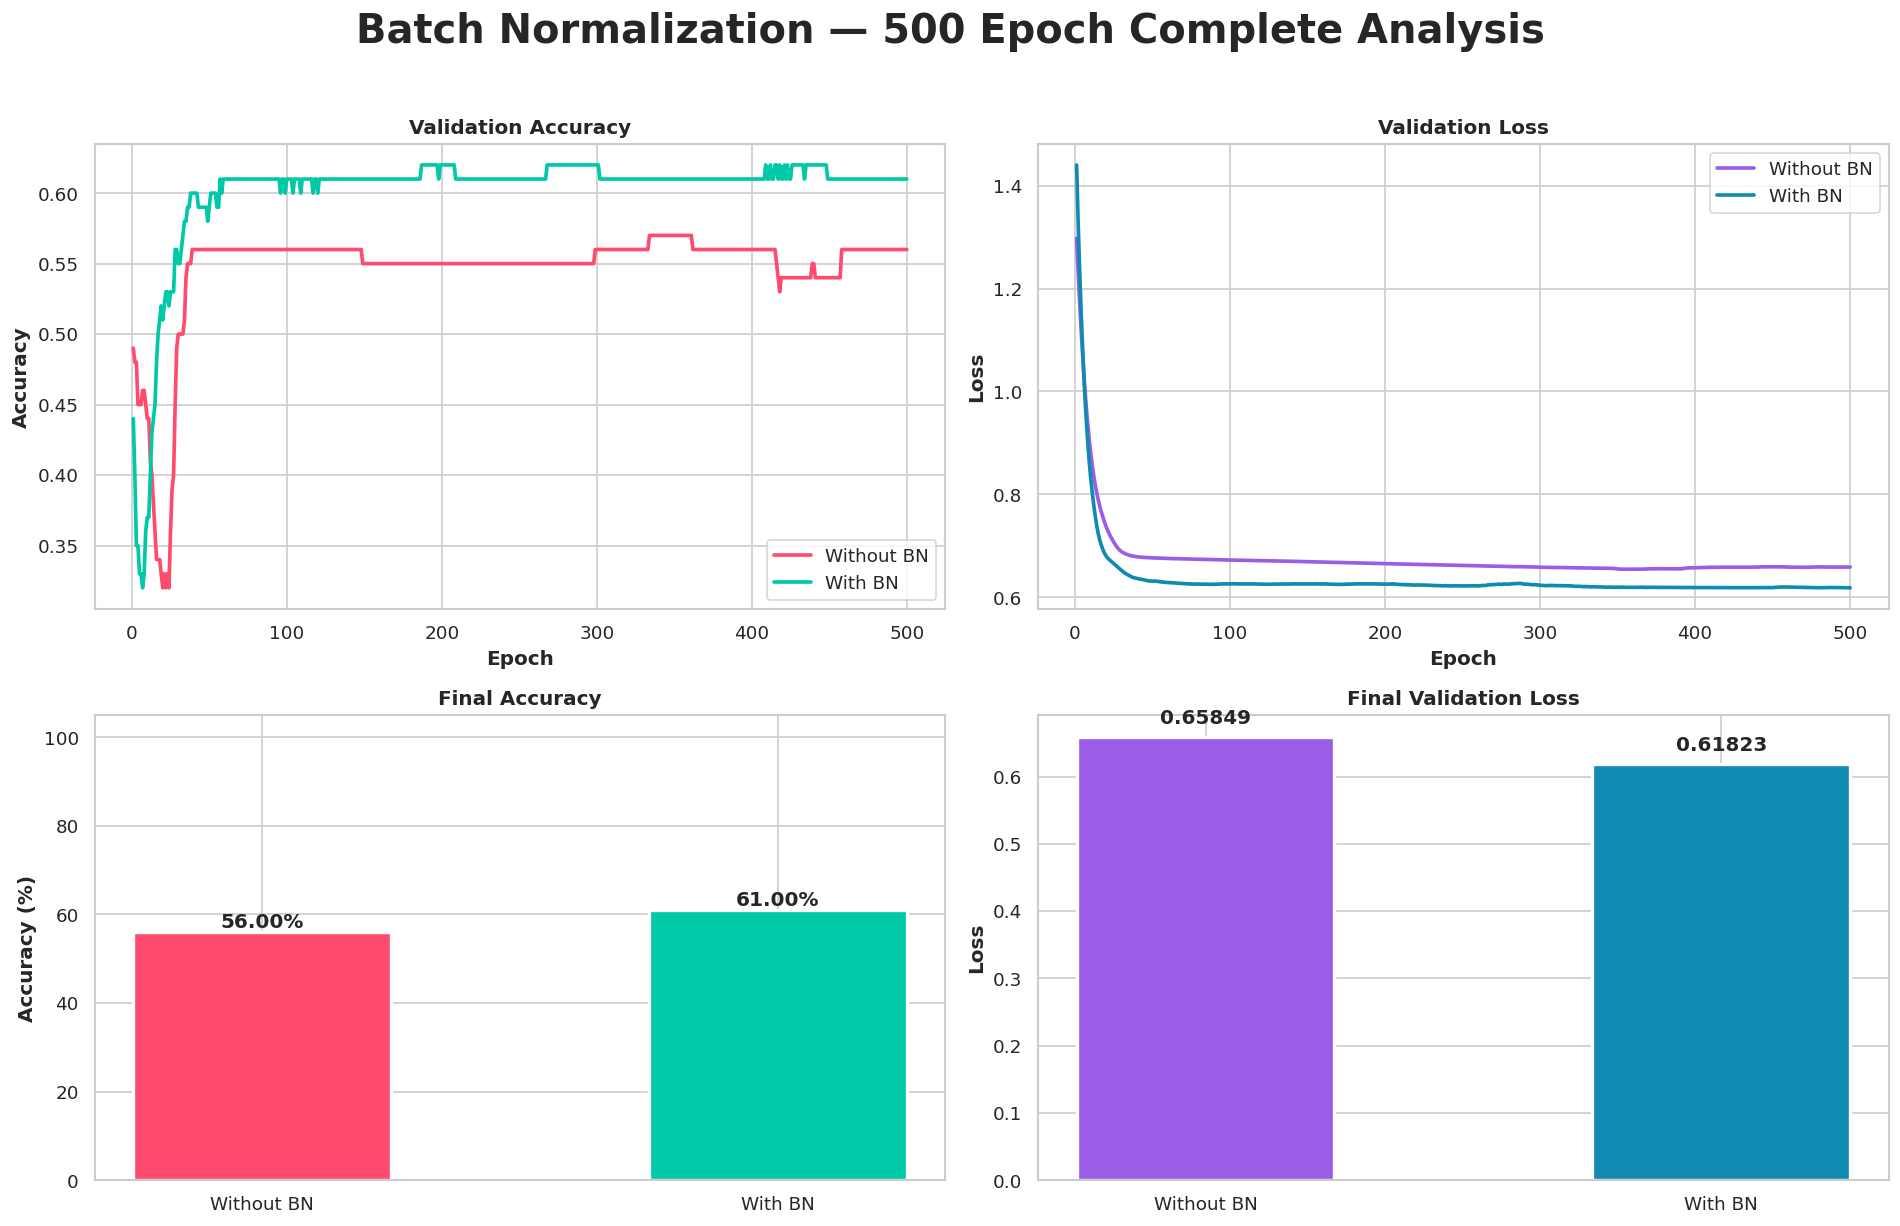

In [30]:
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))

ax1.plot(
    epochs,
    history_without_bn.history["val_accuracy"],
    color="#FF4B6E",
    linewidth=2.2,
    label="Without BN"
)

ax1.plot(
    epochs,
    history_with_bn.history["val_accuracy"],
    color="#00C9A7",
    linewidth=2.2,
    label="With BN"
)

ax1.set_title("Validation Accuracy", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(
    epochs,
    history_without_bn.history["val_loss"],
    color="#9B5DE5",
    linewidth=2.2,
    label="Without BN"
)

ax2.plot(
    epochs,
    history_with_bn.history["val_loss"],
    color="#118AB2",
    linewidth=2.2,
    label="With BN"
)

ax2.set_title("Validation Loss", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

dashboard_models = ["Without BN", "With BN"]

dashboard_accuracy = [
    accuracy_without_bn * 100,
    accuracy_with_bn * 100
]

dashboard_loss = [
    loss_without_bn,
    loss_with_bn
]

bars1 = ax3.bar(
    dashboard_models,
    dashboard_accuracy,
    color=["#FF4B6E", "#00C9A7"],
    width=0.5,
    edgecolor="white",
    linewidth=2
)

ax3.set_title("Final Accuracy", fontweight="bold")
ax3.set_ylabel("Accuracy (%)")
ax3.set_ylim(0, 105)

for bar, value in zip(bars1, dashboard_accuracy):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

bars2 = ax4.bar(
    dashboard_models,
    dashboard_loss,
    color=["#9B5DE5", "#118AB2"],
    width=0.5,
    edgecolor="white",
    linewidth=2
)

ax4.set_title("Final Validation Loss", fontweight="bold")
ax4.set_ylabel("Loss")

for bar, value in zip(bars2, dashboard_loss):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(dashboard_loss) * 0.03,
        f"{value:.5f}",
        ha="center",
        fontweight="bold"
    )

plt.suptitle(
    "Batch Normalization — 500 Epoch Complete Analysis",
    fontsize=24,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

In [31]:
if accuracy_with_bn > accuracy_without_bn:
    winner = "With Batch Normalization"
elif accuracy_without_bn > accuracy_with_bn:
    winner = "Without Batch Normalization"
else:
    winner = "Both models achieved the same validation accuracy"

print("Training Completed: 500 Epochs")
print("Best Model:", winner)
print(f"Accuracy Without BN: {accuracy_without_bn:.4%}")
print(f"Accuracy With BN: {accuracy_with_bn:.4%}")
print(f"Loss Without BN: {loss_without_bn:.6f}")
print(f"Loss With BN: {loss_with_bn:.6f}")

Training Completed: 500 Epochs
Best Model: With Batch Normalization
Accuracy Without BN: 56.0000%
Accuracy With BN: 61.0000%
Loss Without BN: 0.658490
Loss With BN: 0.618225
